In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing, GCNConv
from torch_geometric.transforms import GCNNorm
from torchdiffeq import odeint_adjoint as odeint
from torch_geometric.utils import from_networkx

import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch_geometric.utils import from_networkx
import seaborn as sns
from ipywidgets import interactive
from IPython.display import display
import ipywidgets as widgets
from tqdm.auto import tqdm
sns.set_style("darkgrid")

In [2]:
class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_dim, hidden_dim))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.convs.append(GCNConv(hidden_dim, out_dim))

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        intermediate_embeddings = []
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=0.5, training=self.training)
            intermediate_embeddings.append(x.detach().cpu().numpy())
        return F.log_softmax(x, dim=1), intermediate_embeddings


class GRANDGCNConv(MessagePassing):
    def __init__(self):
        super().__init__(aggr='add')

    def forward(self, t, x, edge_index, edge_weight):
        # The ODE dynamics: dX/dt = (A_norm * X) - X
        # A_norm * X is the message passing result
        return self.propagate(edge_index, x=x, edge_weight=edge_weight) - x

    def message(self, x_j, edge_weight):
        return edge_weight.view(-1, 1) * x_j


class GRAND_GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, integration_time=1.0):
        super().__init__()
        self.encoder = nn.Linear(in_dim, hidden_dim)
        self.ode_block = GRANDGCNConv()
        self.decoder = nn.Linear(hidden_dim, out_dim)
        self.integration_time = torch.tensor([0, integration_time]).float()
        self.gcn_norm_transform = GCNNorm()

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        temp_data = self.gcn_norm_transform(data.clone())
        edge_index_norm, edge_weight_norm = temp_data.edge_index, temp_data.edge_weight
        x = F.relu(self.encoder(x))
        self.integration_time = self.integration_time.to(x.device)
        ode_func = lambda t, y: self.ode_block(t, y, edge_index=edge_index_norm, edge_weight=edge_weight_norm)
        
        solution = odeint(
            ode_func, 
            x, 
            self.integration_time, 
            method='dopri5', 
            rtol=1e-3, 
            atol=1e-4,
            adjoint_params=()
        )
        
        x = solution[1]
        x = self.decoder(x)
        return F.log_softmax(x, dim=1)

In [3]:
m1, m2, m3 = 15, 15, 4 # Two communities of 15, bridge of 4
# These should result in different embeddings for the two communities

G = nx.barbell_graph(m1, m3)
data = from_networkx(G)


data.x = torch.eye(G.number_of_nodes())
data.y = torch.zeros(G.number_of_nodes(), dtype=torch.long)
data.y[:m1] = 0
data.y[m1:m1+m3] = 2
data.y[m1+m3:] = 1

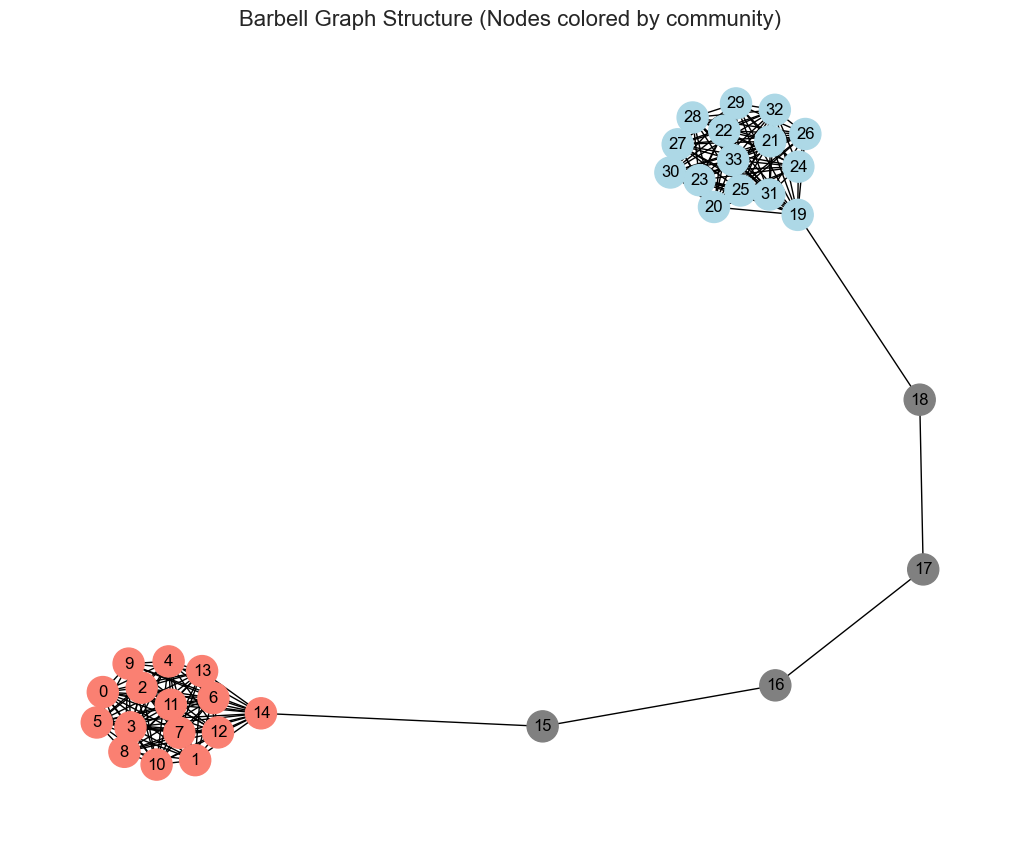

In [4]:
plt.figure(figsize=(10, 8))
color_map = {0: 'salmon', 1: 'lightblue', 2: 'gray'}
node_colors = [color_map[label.item()] for label in data.y]
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500, font_color='black')
plt.title("Barbell Graph Structure (Nodes colored by community)", fontsize=16)
plt.show()


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

In [6]:
NUM_EPOCHS = 200
NUM_GCN_LAYERS = 10
HIDDEN_DIM = 8
INTEGRATION_TIME = 8.0
NUM_TIME_STEPS = 20

In [7]:
# Regular GNN Demonstration

gcn_model = GCN(in_dim=data.x.shape[1], hidden_dim=HIDDEN_DIM, out_dim=3, num_layers=NUM_GCN_LAYERS).to(device)
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01)
gcn_model.train()

for epoch in tqdm(range(5)):
    optimizer.zero_grad()
    out, _ = gcn_model(data)
    loss = F.nll_loss(out[data.y != 2], data.y[data.y != 2]) # Ignore bridge nodes for loss
    loss.backward()
    optimizer.step()

  0%|          | 0/5 [00:00<?, ?it/s]

In [8]:
gcn_model.eval()

_, gcn_embeddings_list = gcn_model(data)


hidden_embeddings = [emb for emb in gcn_embeddings_list[:-1]]
final_embedding = gcn_embeddings_list[-1]

pca_gcn = PCA(n_components=2)
all_hidden_embs_np = torch.tensor(hidden_embeddings).view(-1, HIDDEN_DIM).numpy()
pca_gcn.fit(all_hidden_embs_np)

# Now, transform each step using the SAME fitted PCA
gcn_embeddings_2d = [pca_gcn.transform(emb) for emb in hidden_embeddings]
NUM_GCN_STEPS_TO_VISUALIZE = len(gcn_embeddings_2d)

# Calculate consistent axis limits
x_lims_gcn = (min(e[:,0].min() for e in gcn_embeddings_2d), max(e[:,0].max() for e in gcn_embeddings_2d))
y_lims_gcn = (min(e[:,1].min() for e in gcn_embeddings_2d), max(e[:,1].max() for e in gcn_embeddings_2d))

C:\Users\Nikita\AppData\Local\Temp\ipykernel_36048\757558213.py:10: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  all_hidden_embs_np = torch.tensor(hidden_embeddings).view(-1, HIDDEN_DIM).numpy()


In [9]:
def plot_gcn_step(step):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.gca()
    
    data_to_plot = gcn_embeddings_2d[step]
    sns.scatterplot(x=data_to_plot[:, 0], y=data_to_plot[:, 1], hue=data.y.cpu().numpy(),
                    palette={0: 'salmon', 1: 'lightblue', 2: 'gray'}, s=100, ax=ax, legend='full')
    ax.set_title(f'GCN Embeddings at Hidden Layer {step + 1}', fontsize=16)
    ax.set_xlabel("PCA Component 1"); ax.set_ylabel("PCA Component 2")
    ax.set_xlim(x_lims_gcn); ax.set_ylim(y_lims_gcn)
    
    return fig

In [ ]:
gcn_slider = widgets.IntSlider(min=0, max=NUM_GCN_STEPS_TO_VISUALIZE - 1, step=1, value=0, description='GCN Layer:')

gcn_interactive_plot = interactive(plot_gcn_step, step=gcn_slider)

display(gcn_interactive_plot)

interactive(children=(IntSlider(value=0, description='GCN Layer:', max=8), Output()), _dom_classes=('widget-in…

In [11]:
# GRAND GNN Demonstration

grand_gcn_model = GRAND_GCN(in_dim=data.x.shape[1], hidden_dim=HIDDEN_DIM, out_dim=3, integration_time=INTEGRATION_TIME).to(device)
optimizer = torch.optim.Adam(grand_gcn_model.parameters(), lr=0.01)
grand_gcn_model.train()

for epoch in tqdm(range(NUM_EPOCHS)):
    optimizer.zero_grad()
    out = grand_gcn_model(data)
    loss = F.nll_loss(out[data.y != 2], data.y[data.y != 2])
    loss.backward()
    optimizer.step()


grand_gcn_model.eval()
with torch.no_grad():
    gcn_norm_transform = GCNNorm()
    temp_data = gcn_norm_transform(data.clone())
    edge_index_norm, edge_weight_norm = temp_data.edge_index, temp_data.edge_weight
    
    x0 = grand_gcn_model.encoder(data.x)
    times = torch.linspace(0, INTEGRATION_TIME, NUM_TIME_STEPS).to(device)
    ode_func = lambda t, y: grand_gcn_model.ode_block(t, y, edge_index=edge_index_norm, edge_weight=edge_weight_norm)

    
    grand_solution = odeint(
        ode_func, 
        x0, 
        times,
        adjoint_params=()
    ) 


all_grand_embeddings = grand_solution.view(-1, HIDDEN_DIM).cpu().numpy()
pca_grand = PCA(n_components=2)
pca_grand.fit(all_grand_embeddings)
grand_embeddings_2d = [pca_grand.transform(emb.cpu().numpy()) for emb in grand_solution]
x_lims_grand = (min(e[:,0].min() for e in grand_embeddings_2d), max(e[:,0].max() for e in grand_embeddings_2d))
y_lims_grand = (min(e[:,1].min() for e in grand_embeddings_2d), max(e[:,1].max() for e in grand_embeddings_2d))

  0%|          | 0/200 [00:00<?, ?it/s]

In [12]:
def plot_grand_step(step):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.gca()

    current_time = times[step].item()
    data_to_plot = grand_embeddings_2d[step]
    sns.scatterplot(x=data_to_plot[:, 0], y=data_to_plot[:, 1], hue=data.y.cpu().numpy(),
                    palette={0: 'salmon', 1: 'lightblue', 2: 'gray'}, s=100, ax=ax, legend='full')
    ax.set_title(f'GRAND-GCN Embeddings at Time t = {current_time:.2f}', fontsize=16)
    ax.set_xlabel("PCA Component 1"); ax.set_ylabel("PCA Component 2")
    ax.set_xlim(x_lims_grand); ax.set_ylim(y_lims_grand)
    
    return fig

In [13]:
grand_slider = widgets.IntSlider(min=0, max=NUM_TIME_STEPS - 1, step=1, value=0, description='Time Step:')
display(interactive(plot_grand_step, step=grand_slider))

interactive(children=(IntSlider(value=0, description='Time Step:', max=19), Output()), _dom_classes=('widget-i…